In [60]:
import numpy as np
import matplotlib.pyplot as plt
from src.distributions import gaussian

### **Part 1: Synthetic Gaussian Data**

#### **Shared Isotropic Covariance**

In [61]:
# generating 2D gaussian centered around 3 different means (3 classes)

rng = np.random.default_rng(42)
n = 10_000
means = np.array([[0.0, 0.0], [4.0, 0.0], [2.0, 4.0]])

class_samples = []
for mean in means:
    X = np.column_stack((
        gaussian(mean[0], 1, n, rng),
        gaussian(mean[1], 1, n, rng)
    ))
    class_samples.append(X)

print([X.shape for X in class_samples])

[(10000, 2), (10000, 2), (10000, 2)]


In [62]:
# shuffling the data before spliting

np.random.seed(42)
indices = np.random.permutation(len(X[:, 0]))

shuffled_class_samples = []

for samples in class_samples:
    shuffled_samples = samples[indices]
    shuffled_class_samples.append(shuffled_samples)

In [63]:
# spliting the data points

train_end = int(0.8 * len(X[:, 0]))

train_class_samples = []
test_class_samples = []

for sample in shuffled_class_samples:
    train_class_samples.append(sample[:train_end, :])
    test_class_samples.append(sample[train_end:, :])

for i in range(len(train_class_samples)):
    print(f"Class {i+1} train_data shape : {train_class_samples[i].shape} and test_data shape : {test_class_samples[i].shape}")

Class 1 train_data shape : (8000, 2) and test_data shape : (2000, 2)
Class 2 train_data shape : (8000, 2) and test_data shape : (2000, 2)
Class 3 train_data shape : (8000, 2) and test_data shape : (2000, 2)


In [64]:
# estimating the parameters

train_class_mean_est = []
train_class_cov_est = []

for sample in train_class_samples:
    mu_hat = [sample[:, 0].mean(), sample[:, 1].mean()]
    train_class_mean_est.append(np.array([mu_hat[0], mu_hat[1]]))

print(train_class_mean_est)

[array([-0.00690185,  0.01598336]), array([ 4.01010049e+00, -2.02437662e-03]), array([2.00097768, 4.00330714])]


In [65]:
# one isotropic covariance shared by all three classes

squared_distance_sum = 0
for sample, mu_hat in zip(train_class_samples, train_class_mean_est):
    squared_distance_sum += np.sum((sample - mu_hat) ** 2)

total_points = sum(sample.shape[0] for sample in train_class_samples)
shared_variance = squared_distance_sum / (2 * total_points)
shared_cov_est = shared_variance * np.eye(2)

print("Shared variance:", shared_variance)
print("Shared covariance:\n", shared_cov_est)

Shared variance: 1.005064652491484
Shared covariance:
 [[1.00506465 0.        ]
 [0.         1.00506465]]


In [ ]:
# Gaussian log score for one point and one class

def gaussian_score(point, mu, cov):
    difference = point - mu
    d_squared = difference @ np.linalg.inv(cov) @ difference
    return -0.5 * d_squared - 0.5 * np.log(np.linalg.det(cov))

# classify one held-out point
point = test_class_samples[0][0]
scores = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]
predicted_class = np.argmax(scores) + 1

print("Point:", point)
print("Gaussian scores:", scores)
print("Predicted class:", predicted_class)

Point: [ 1.42360238 -1.62025687]
Gaussian scores: [np.float64(-2.3549626112433413), np.float64(-4.63592255258004), np.float64(-15.903449210406118)]
Predicted class: 1


In [67]:
# classify all held-out points

test_class_predictions = []
for sample in test_class_samples:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]
        predictions.append(np.argmax(scores) + 1)
    test_class_predictions.append(np.array(predictions))

print([len(predictions) for predictions in test_class_predictions])

[2000, 2000, 2000]


In [68]:
# rows: true class, columns: predicted class

confusion_matrix = np.zeros((3, 3), dtype=int)

for true_class, predictions in enumerate(test_class_predictions):
    for predicted_class in predictions:
        confusion_matrix[true_class, predicted_class - 1] += 1

print(confusion_matrix)
print("Accuracy:", np.trace(confusion_matrix) / confusion_matrix.sum())

[[1934   45   21]
 [  35 1944   21]
 [  18   28 1954]]
Accuracy: 0.972


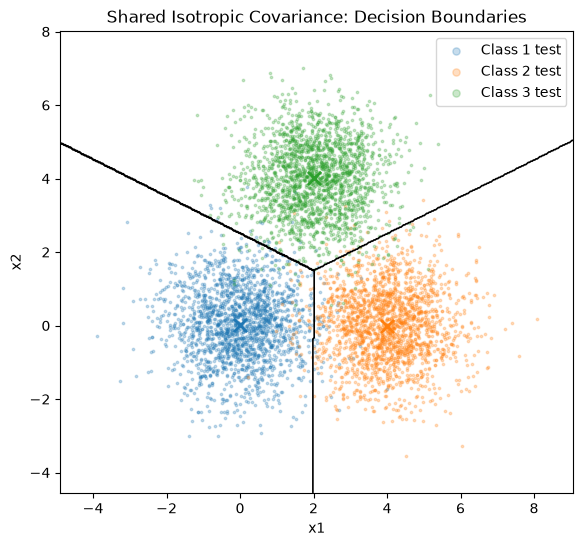

In [71]:
# decision regions from the estimated Gaussian scores

test_points = np.vstack(test_class_samples)
x_values = np.linspace(test_points[:, 0].min() - 1, test_points[:, 0].max() + 1, 400)
y_values = np.linspace(test_points[:, 1].min() - 1, test_points[:, 1].max() + 1, 400)
x_grid, y_grid = np.meshgrid(x_values, y_values)
regions = np.zeros(x_grid.shape, dtype=int)
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        scores = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]
        regions[i, j] = np.argmax(scores)

colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(8, 6))
plt.contour(x_grid, y_grid, regions, levels=[0.5, 1.5], colors="black", linewidths=1.2)
for k, sample in enumerate(test_class_samples):
    plt.scatter(sample[:, 0], sample[:, 1], s=3, alpha=0.25, color=colors[k], label=f"Class {k + 1} test")
for k, mu_hat in enumerate(train_class_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=90, linewidths=2, color=colors[k])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Shared Isotropic Covariance: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(x_values[0], x_values[-1])
plt.ylim(y_values[0], y_values[-1])
plt.legend(markerscale=3)
plt.show()